In [1]:
import pandas as pd
import numpy as np
import datetime
import matplotlib.pyplot as plt
from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, r2_score

plt.style.use('default')
traffic_df = pd.read_csv("Metro_Interstate_Traffic_Volume.csv")
traffic_df = pd.DataFrame(traffic_df)

traffic_df['date_time'] = pd.to_datetime(traffic_df['date_time'], format='%d-%m-%Y %H:%M')
traffic_df = traffic_df.sort_values('date_time').reset_index(drop=True)

traffic_df['isHoliday'] = pd.notna(traffic_df['holiday']).astype('int')
traffic_df['hour'] = traffic_df['date_time'].dt.hour
traffic_df['dayOfWeek'] = traffic_df['date_time'].dt.weekday
traffic_df['month'] = traffic_df['date_time'].dt.month
traffic_df['isWeekend'] = (traffic_df['date_time'].dt.weekday >= 5).astype(int)
traffic_df['hour_sin'] = np.sin(2 * np.pi * traffic_df['hour'] / 24.0)
traffic_df['hour_cos'] = np.cos(2 * np.pi * traffic_df['hour'] / 24.0)

features_test1 = ['dayOfWeek', 'month', 'hour_sin', 'hour_cos', 'isHoliday']
X1 = traffic_df[features_test1]
preprocessor_test1 = ColumnTransformer(
    transformers=[
        ('num1', StandardScaler(), features_test1),
        ('cat1', OneHotEncoder(handle_unknown='ignore', sparse_output=False), features_test1)
    ])

num_features_test2 = ['temp', 'rain_1h', 'snow_1h', 'clouds_all', 'dayOfWeek', 'month', 'hour_sin', 'hour_cos',
                      'isHoliday']
cat_features_test2 = ['weather_main']
X2 = traffic_df[num_features_test2 + cat_features_test2]
preprocessor_test2 = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_features_test2),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_features_test2)
    ])

y = traffic_df['traffic_volume'].values

desc = traffic_df.describe()
desc.to_csv("traffic_descr.csv")

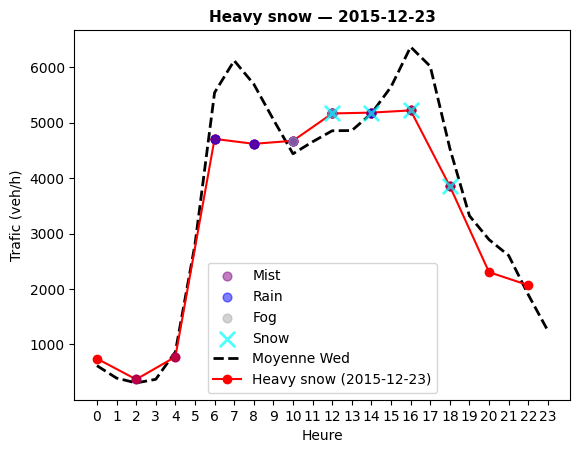

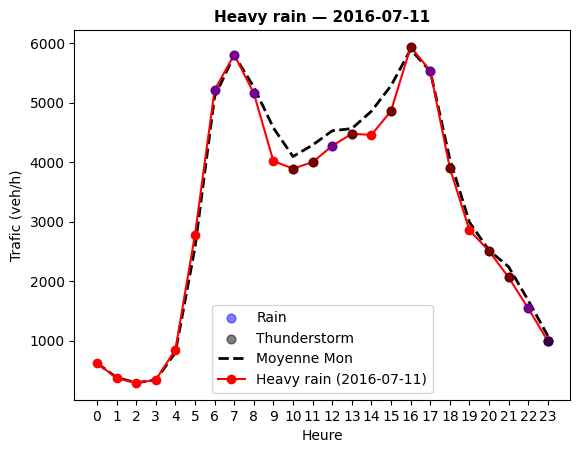

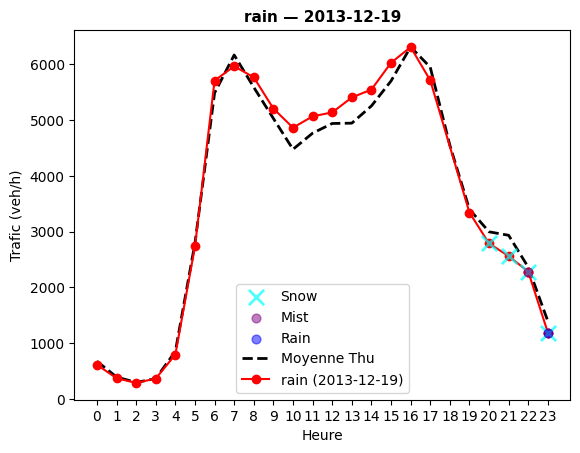

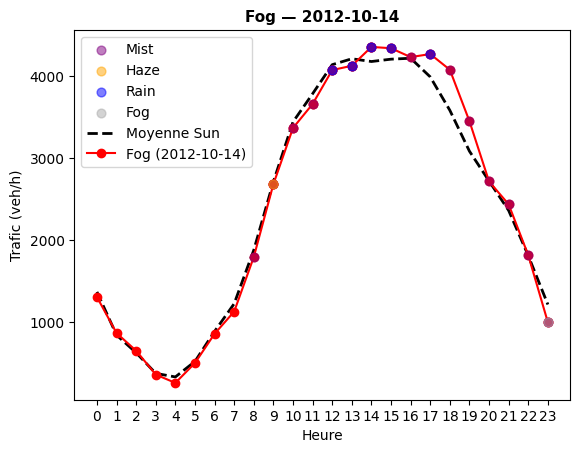

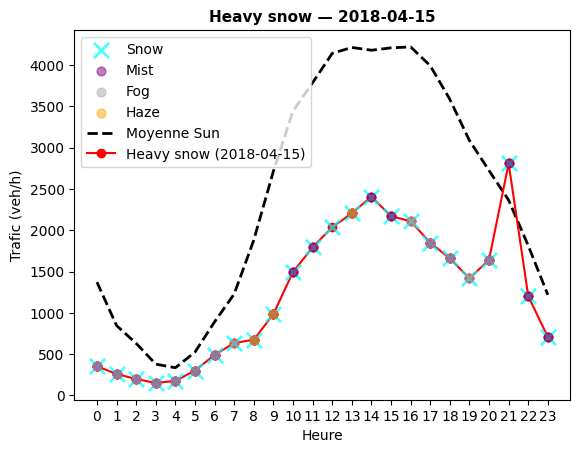

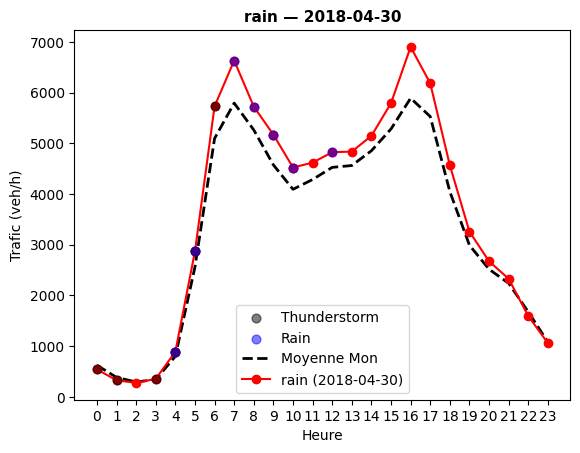

In [46]:
day_names = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]


def plot_special_day(df, special_date, event_label):
    special_date = pd.to_datetime(special_date).date()
    special = df[df['date_time'].dt.date == special_date].sort_values('hour')
    weekday = special['dayOfWeek'].iloc[0]
    baseline = df[df['dayOfWeek'] == weekday].groupby('hour')['traffic_volume'].mean()

    excluded_weather = ['Clear', 'Clouds', 'Drizzle']

    weather_events = [
        w for w in special['weather_main'].unique()
        if w not in excluded_weather
    ]

    # Optional custom colors
    weather_colors = {
        'Clear': 'gold',
        'Clouds': 'gray',
        'Rain': 'blue',
        'Snow': 'cyan',
        'Mist': 'purple',
        'Fog': 'darkgray',
        'Thunderstorm': 'black',
        'Drizzle': 'deepskyblue',
        'Haze': 'orange',
        'Smoke': 'brown'
    }

    for weather in weather_events:

        weather_mask = special['weather_main'] == weather

        # Snow -> crosses
        if weather == 'Snow':

            plt.scatter(
                special.loc[weather_mask, 'hour'],
                special.loc[weather_mask, 'traffic_volume'],
                s=120,
                marker='x',
                linewidths=2,
                color=weather_colors.get(weather, 'cyan'), alpha=0.7,
                label=weather,
                zorder=5
            )

        # Everything else -> circles
        else:

            plt.scatter(
                special.loc[weather_mask, 'hour'],
                special.loc[weather_mask, 'traffic_volume'],
                s=40,
                marker='o',
                color=weather_colors.get(weather, 'green'), alpha=0.5,
                label=weather,
                zorder=5
            )
    plt.plot(baseline.index, baseline.values, 'k--', linewidth=2,
             label=f'Moyenne {day_names[weekday]}')
    plt.plot(special['hour'], special['traffic_volume'],
             color="red", marker='o',
             label=f'{event_label} ({special_date})')
    # ax.fill_between(special['hour'].values,
    #                 baseline.reindex(special['hour']).values,
    #                 special['traffic_volume'].values,
    #                 alpha=0.2, color='blue')
    plt.title(f'{event_label} — {special_date}', fontsize=11, fontweight='bold')
    plt.xlabel('Heure')
    plt.ylabel('Trafic (veh/h)')
    plt.legend()
    plt.xticks(range(0, 24))
    plt.show()


plot_special_day(traffic_df, '2015-12-23', 'Heavy snow')
plot_special_day(traffic_df, '2016-07-11', 'Heavy rain')
plot_special_day(traffic_df, '2013-12-19', 'rain')
plot_special_day(traffic_df, '2012-10-14', 'Fog')
plot_special_day(traffic_df, '2018-04-15', 'Heavy snow')
plot_special_day(traffic_df, '2018-04-30', 'rain')

In [12]:
from sklearn.linear_model import LassoCV

tss = TimeSeriesSplit(n_splits=10, gap=0)
for fold_id, (train_index, test_index) in enumerate(tss.split(traffic_df)):
    # Split data sequentially
    X_tr, X_te = X2.iloc[train_index], X2.iloc[test_index]
    y_tr, y_te = y[train_index], y[test_index]

    X_tr = preprocessor_test2.fit_transform(X_tr)
    X_te = preprocessor_test2.transform(X_te)

    inner_tss = TimeSeriesSplit(n_splits=5)
    LassoCV_reg = LassoCV(cv=inner_tss, random_state=42).fit(X_tr, y_tr)
    y_pred_lassoCV = LassoCV_reg.predict(X_te)

    print("R2:", r2_score(y_te, y_pred_lassoCV))
    print("RMSE:", np.sqrt(mean_squared_error(y_te, y_pred_lassoCV)))

    feature_names = preprocessor_test2.get_feature_names_out()
    coef_df = pd.DataFrame({
        'feature': feature_names,
        'coefficient': LassoCV_reg.coef_.round(2)
    })
    coef_df.to_csv(f'Coef {fold_id + 1}.csv')
    coef_df['abs_coef'] = np.abs(coef_df['coefficient'])
    #print(coef_df.sort_values('abs_coef', ascending=False))
    if fold_id==8:
        y_pred_fold9 = y_pred_lassoCV
        y_real_fold9 = y_te
        test_index_fold9 = test_index

    plt.scatter(y_te, y_pred_lassoCV, c='y', alpha=0.3)
    plt.plot(y_te, y_te, c='r', alpha=0.6, ls='--')
    plt.xlim(y_te.min() - 1, y_te.max() + 1)
    plt.ylim(y_te.min() - 1, y_te.max() + 1)
    plt.xlabel('Observed target')
    plt.ylabel('Predicted target')
    #plt.show()
    plt.close()

R2: 0.6820145391776067
RMSE: 1166.002483307308
R2: 0.6726691501407277
RMSE: 1120.6840872109349
R2: 0.6844095446493894
RMSE: 1122.3465188732819
R2: 0.6815550897575062
RMSE: 1146.4211540636923
R2: -1.3920292300583026
RMSE: 3045.3960724833996
R2: 0.6578892173746941
RMSE: 1097.6612974023942
R2: 0.6724477874700243
RMSE: 1137.8315174251932
R2: 0.6688275359994145
RMSE: 1164.9052202845237
R2: 0.6479406611783063
RMSE: 1165.1680134057713
R2: 0.6669037351082314
RMSE: 1127.9102682300222


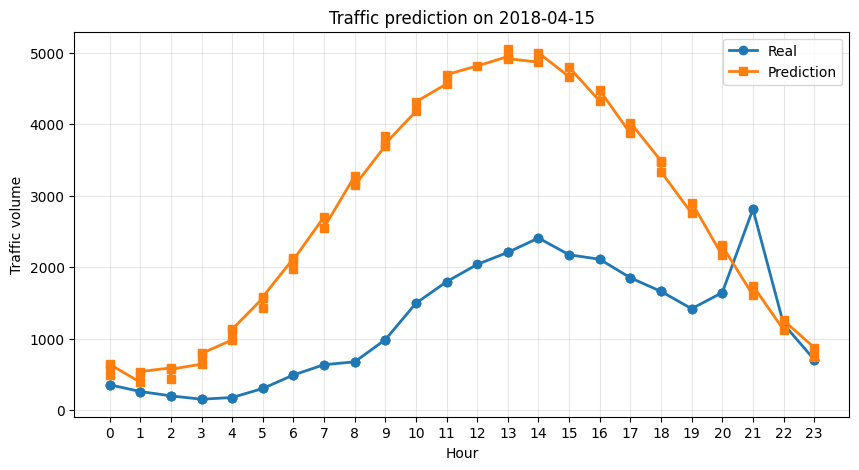

In [19]:
# ---------------------------------------------------------
# Select one day
# ---------------------------------------------------------

special_date = pd.to_datetime('2018-04-15').date()

dates_test = traffic_df.iloc[test_index_fold9]['date_time'].reset_index(drop=True)

day_mask = dates_test.dt.date == special_date

dates_day = dates_test[day_mask]

y_real_day = y_real_fold9[day_mask]
y_pred_day = y_pred_fold9[day_mask]

# ---------------------------------------------------------
# Plot
# ---------------------------------------------------------

hours = dates_day.dt.hour

plt.figure(figsize=(10,5))

plt.plot(hours, y_real_day, marker='o', linewidth=2, label='Real')
plt.plot(hours, y_pred_day, marker='s', linewidth=2, label='Prediction')

plt.xticks(range(24))
plt.xlabel('Hour')
plt.ylabel('Traffic volume')
plt.title(f'Traffic prediction on {special_date}')

plt.grid(True, alpha=0.3)
plt.legend()

plt.show()

R2: 0.8987354314104417
RMSE: 624.8983495524277


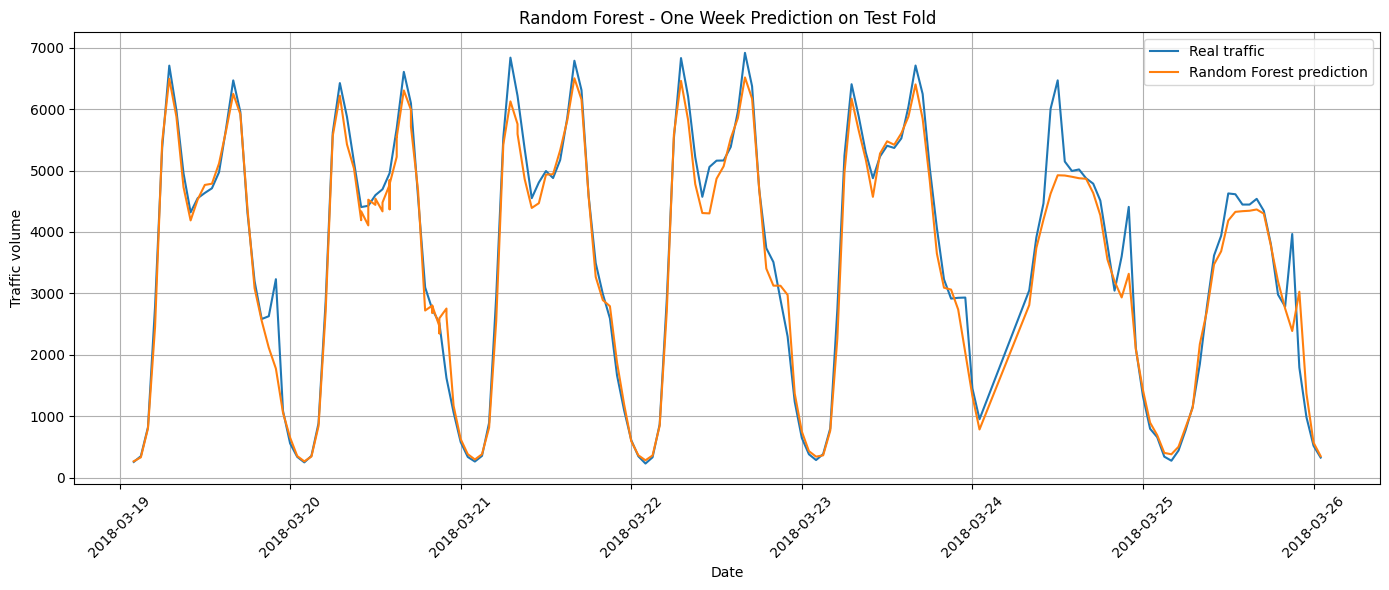

                           feature  importance
18             remainder__hour_cos    0.670063
17             remainder__hour_sin    0.174184
15            remainder__dayOfWeek    0.110058
11                 remainder__temp    0.025221
16                remainder__month    0.008452
14           remainder__clouds_all    0.004830
12              remainder__rain_1h    0.002733
1         cat__weather_main_Clouds    0.001345
0          cat__weather_main_Clear    0.000602
5           cat__weather_main_Mist    0.000560
8           cat__weather_main_Snow    0.000458
4           cat__weather_main_Haze    0.000431
6           cat__weather_main_Rain    0.000319
3            cat__weather_main_Fog    0.000248
10  cat__weather_main_Thunderstorm    0.000186


In [33]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import TimeSeriesSplit

# ---------------------------------------------------------
# Time series split
# ---------------------------------------------------------

tss = TimeSeriesSplit(n_splits=10)

# Take ONLY the last fold
for fold_id, (train_index2, test_index2) in enumerate(tss.split(traffic_df)):
    if fold_id == 8:
        train_index = train_index2
        test_index = test_index2

X_tr, X_te = X2.iloc[train_index], X2.iloc[test_index]
y_tr, y_te = y[train_index], y[test_index]

# ---------------------------------------------------------
# Preprocessing
# ---------------------------------------------------------
# Random Forest does NOT require scaling,
# but we still need one-hot encoding.

preprocessor_rf = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_features_test2)
    ],
    remainder='passthrough'
)

X_tr = preprocessor_rf.fit_transform(X_tr)
X_te = preprocessor_rf.transform(X_te)

# ---------------------------------------------------------
# Train Random Forest
# ---------------------------------------------------------

RF_reg = RandomForestRegressor(
    n_estimators=100,
    max_depth=15,
    random_state=42,
    n_jobs=-1
)

RF_reg.fit(X_tr, y_tr)

# ---------------------------------------------------------
# Predictions
# ---------------------------------------------------------

y_pred = RF_reg.predict(X_te)

print("R2:", r2_score(y_te, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_te, y_pred)))

# ---------------------------------------------------------
# Select ONE WEEK from the test fold
# ---------------------------------------------------------

dates_test = traffic_df.iloc[test_index]['date_time'].reset_index(drop=True)

start_date = dates_test.iloc[3000]
end_date = start_date + pd.Timedelta(days=7)

week_mask = (dates_test >= start_date) & (dates_test < end_date)

dates_week = dates_test[week_mask]

y_real_week = y_te[week_mask]
y_pred_week = y_pred[week_mask]

# ---------------------------------------------------------
# Plot
# ---------------------------------------------------------

plt.figure(figsize=(14, 6))

plt.plot(dates_week, y_real_week, label='Real traffic')
plt.plot(dates_week, y_pred_week, label='Random Forest prediction')

plt.xlabel('Date')
plt.ylabel('Traffic volume')
plt.title('Random Forest - One Week Prediction on Test Fold')

plt.legend()
plt.grid(True)

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# Feature importance
# ---------------------------------------------------------

feature_names = preprocessor_rf.get_feature_names_out()

importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': RF_reg.feature_importances_
})

importance_df = importance_df.sort_values(
    by='importance',
    ascending=False
)

print(importance_df.head(15))

In [68]:
def plot_special_days_predictions(
    traffic_df,
    dates_test,
    y_real,
    y_pred_models,
    special_days,
    model_labels=None
):
    """
    y_pred_models: list of arrays (e.g. [LSTM_pred, RF_pred])
    model_labels: list of names for plotting
    """

    import numpy as np
    import pandas as pd
    import matplotlib.pyplot as plt

    day_names = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]

    weather_colors = {
        'Clear': 'gold',
        'Clouds': 'gray',
        'Rain': 'blue',
        'Snow': 'cyan',
        'Mist': 'purple',
        'Fog': 'darkgray',
        'Thunderstorm': 'black',
        'Drizzle': 'deepskyblue',
        'Haze': 'orange',
        'Smoke': 'brown'
    }

    excluded_weather = ['Clear', 'Clouds', 'Drizzle']

    y_real = np.asarray(y_real)
    y_pred_models = [np.asarray(p) for p in y_pred_models]

    if model_labels is None:
        model_labels = [f"Model {i}" for i in range(len(y_pred_models))]

    for special_date, event_label in special_days:

        special_date = pd.to_datetime(special_date).date()

        special = (
            traffic_df[
                traffic_df['date_time'].dt.date == special_date
            ].sort_values('hour')
        )

        if len(special) == 0:
            continue

        weekday = special['dayOfWeek'].iloc[0]

        baseline = (
            traffic_df[traffic_df['dayOfWeek'] == weekday]
            .groupby('hour')['traffic_volume']
            .mean()
        )

        # -----------------------------
        # test fold extraction
        # -----------------------------
        day_mask = dates_test.dt.date == special_date

        if day_mask.sum() == 0:
            continue

        dates_day = dates_test[day_mask]


        plot_df = pd.DataFrame({
            "hour": dates_day.dt.hour,
            "real": y_real[day_mask]
        })

        # add all prediction models
        for i, p in enumerate(y_pred_models):
            plot_df[f"pred_{i}"] = p[day_mask]

        # -------------------------------------------------
        # Keep only first occurrence of each hour
        # -------------------------------------------------
        plot_df = plot_df.drop_duplicates(subset="hour", keep="first")

        # sort just in case
        plot_df = plot_df.sort_values("hour")

        hours = plot_df["hour"].values
        y_real_day = plot_df["real"].values
        y_pred_days = [
            plot_df[f"pred_{i}"].values
            for i in range(len(y_pred_models))
        ]

        # -----------------------------
        # plotting
        # -----------------------------
        plt.figure(figsize=(6, 4))

        # Weather
        weather_events = [
            w for w in special['weather_main'].unique()
            if w not in excluded_weather
        ]

        for weather in weather_events:
            mask = special['weather_main'] == weather
            if weather == 'Snow':
                plt.scatter(
                    special.loc[mask, 'hour'],
                    special.loc[mask, 'traffic_volume'],
                    s=120,
                    marker='x',
                    linewidths=2,
                    color=weather_colors.get(weather, 'cyan'), alpha=0.7,
                    label=weather,
                    zorder=5
                )
            # Everything else -> circles
            else:
                plt.scatter(
                    special.loc[mask, 'hour'],
                    special.loc[mask, 'traffic_volume'],
                    s=40,
                    marker='o',
                    color=weather_colors.get(weather, 'green'), alpha=0.5,
                    label=weather,
                    zorder=5
                )

        # baseline
        plt.plot(
            baseline.index,
            baseline.values,
            'k--',
            label=f'Average {day_names[weekday]}'
        )

        # real
        plt.plot(
            hours,
            y_real_day,
            '-o',
            color='red',
            label='Real'
        )

        # predictions (multiple models)
        colors = ['blue', 'green', 'purple', 'orange']

        for i, y_pred_day in enumerate(y_pred_days):
            plt.plot(
                hours,
                y_pred_day,
                '--',
                color=colors[i % len(colors)],
                label=model_labels[i]
            )

        plt.title(f'{event_label} ({special_date})')
        plt.xlabel('Hour')
        plt.ylabel('Traffic volume')
        plt.xticks(range(0, 24))
        plt.grid(alpha=0.3)
        plt.legend()
        plt.tight_layout()
        plt.savefig(f'plots/{event_label} ({special_date}).png')
        plt.show()

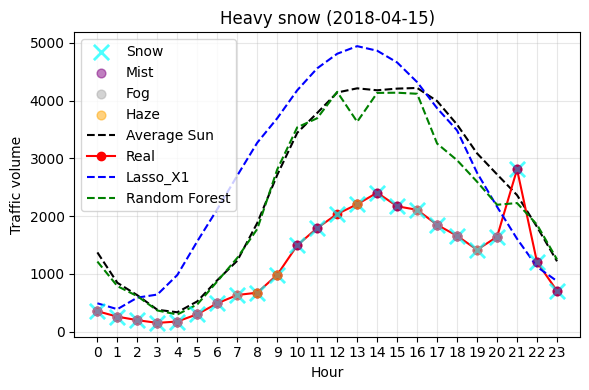

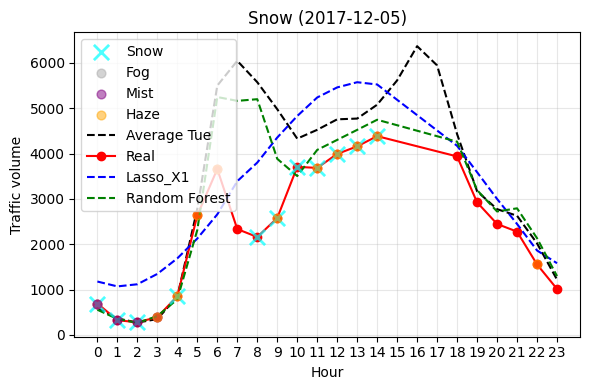

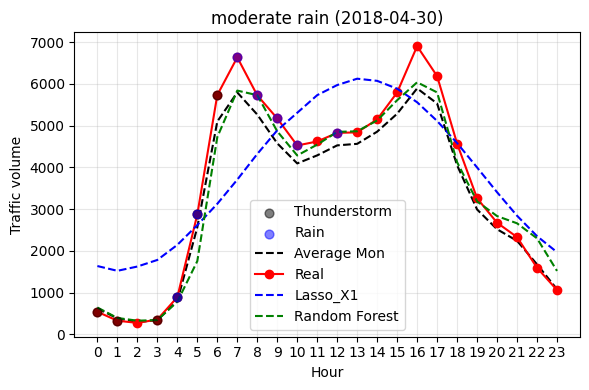

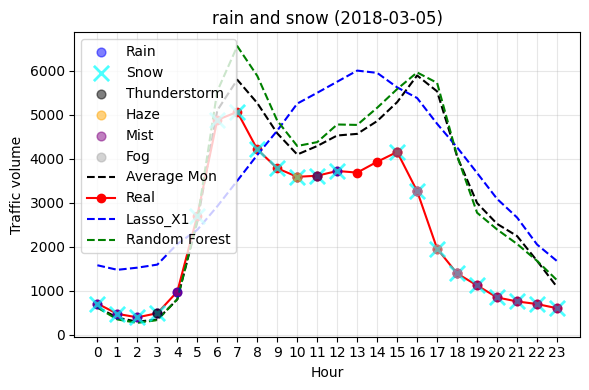

In [69]:
special_days = [
    #('2015-12-23', 'Heavy snow'),
    #('2016-07-11', 'Heavy rain'),
    #('2013-12-19', 'Rain'),
    #('2012-10-14', 'Fog'),
    ('2018-04-15', 'Heavy snow'),
    ('2017-12-05', 'Snow'),
    ('2018-04-30', 'moderate rain'),
    ('2018-03-05', 'rain and snow')

]

dates_test = traffic_df.iloc[test_index_fold9]['date_time'].reset_index(drop=True)

plot_special_days_predictions(
    traffic_df=traffic_df,
    dates_test=dates_test,
    y_real=y_te,
    y_pred_models=[y_pred_fold9, y_pred],
    special_days=special_days,
    model_labels=["Lasso_X1", "Random Forest"]
)